Recall Probability by Lag

Repeated items benefit from spacing: recall improves as more study items intervene between presentations. This notebook compares observed repetition-lag curves with a control dataset and lets you flip between binned and full-resolution views via the `mode` parameter.

Switch `mode` to `'full'` to examine every lag bucket individually.

Adjust `ctrl_query` to redefine the baseline control population.

In [1]:
import os

from jaxcmr.analyses.rpl import (
    infer_max_lag,
    plot_full_rpl,
    plot_rpl,
    subject_binned_rpl,
    subject_full_rpl,
    test_rpl_slope,
    test_rpl_slope_vs_control,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset


In [2]:
data_name = "LohnasKahana2014"
data_query = "data['list_type'] == 4"
ctrl_query = "data['list_type'] == 1"
mode = "binned"  # options: 'binned', 'full'


In [3]:
project_root = find_project_root()
data_path = os.path.join(project_root, "data", f"{data_name}.h5")

data = load_data(data_path)
trial_mask = generate_trial_mask(data, data_query)

control_dataset = make_control_dataset(data, data_query, ctrl_query, 10)
control_mask = generate_trial_mask(control_dataset, data_query)

datasets = [data, control_dataset]
masks = [trial_mask, control_mask]

max_lag = infer_max_lag(data["pres_itemnos"], data["pres_itemnos"].shape[1])
plotting_function = plot_rpl if mode == "binned" else plot_full_rpl
subject_function = subject_binned_rpl if mode == "binned" else subject_full_rpl


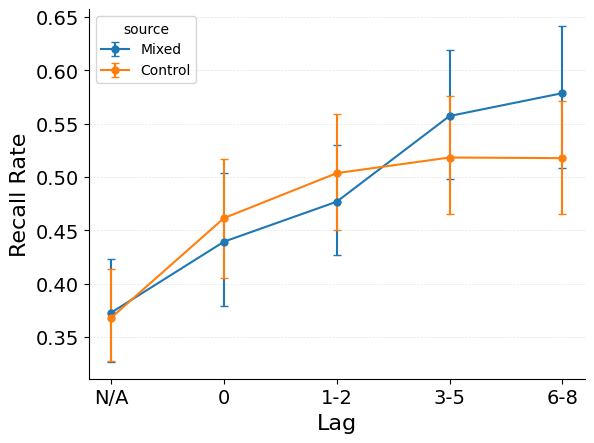

In [4]:

plotting_function(
    datasets, 
    masks, 
    labels=["Mixed", "Control"], 
    contrast_name="source"
);


In [5]:
observed_rpl = subject_function(data, trial_mask, max_lag)
control_rpl = subject_function(control_dataset, control_mask, max_lag)

observed_result = test_rpl_slope(observed_rpl, mode=mode)
control_result = test_rpl_slope(control_rpl, mode=mode)
comparison_result = test_rpl_slope_vs_control(observed_rpl, control_rpl, mode=mode)

print()
print("=" * 60)
print("Spacing Effect Slope: Observed")
print("=" * 60)
print("H0: The recall-probability-by-lag slope is 0.")
print(observed_result)

print()
print("=" * 60)
print("Spacing Effect Slope: Control")
print("=" * 60)
print("H0: The recall-probability-by-lag slope is 0.")
print(control_result)

print()
print("=" * 70)
print("Observed vs Control: Spacing Effect Slope")
print("=" * 70)
print("H0: The observed and control slopes are equal.")
print(comparison_result)



Spacing Effect Slope: Observed
H0: The recall-probability-by-lag slope is 0.
N=35
Mean slope: 0.0206
t-stat: 5.513 p=0.0000
W-stat: 70.0 p=0.0000

Spacing Effect Slope: Control
H0: The recall-probability-by-lag slope is 0.
N=35
Mean slope: 0.0071
t-stat: 5.338 p=0.0000
W-stat: 65.0 p=0.0000

Observed vs Control: Spacing Effect Slope
H0: The observed and control slopes are equal.
N=35
Mean slope (observed): 0.0206
Mean slope (control): 0.0071
Mean difference: 0.0136
t-stat: 3.467 p=0.0014
W-stat: 122.0 p=0.0011
